# Phase 0 — EDA: the multi-label + imbalance shape of Jigsaw

**Learning goal:** understand the shape of the data *before* modeling.

Two properties drive every later decision in this project:

1. **Multi-label, not multi-class.** Labels co-occur — a comment can be `toxic` *and*
   `obscene` *and* `insult` simultaneously. This is why Phase 3 uses independent sigmoids
   rather than a softmax.
2. **Severe class imbalance.** Most comments carry no label at all, and the rarest label
   appears in well under 1% of rows. This is why accuracy is disqualified as a headline
   metric in Phase 2, and why Phase 4 calibrates a threshold per label.

In [1]:
import json
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.config import LABELS, RESULTS, SEED, set_seed, setup_logging
from src.data import build_label_matrix, load_raw, load_splits

setup_logging()
set_seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df = load_raw()
Y = build_label_matrix(df)
n = len(df)
print(f"{n:,} comments x {len(LABELS)} labels -> Y{Y.shape}, dtype={Y.dtype}")

18:44:30 | INFO    | src.config | seed set to 42


18:44:31 | INFO    | src.data | loaded 159571 labeled comments from train.csv


18:44:31 | INFO    | src.data | label matrix (159571, 6) | positives per label: {'toxic': 15294, 'severe_toxic': 1595, 'obscene': 8449, 'threat': 478, 'insult': 7877, 'identity_hate': 1405}


159,571 comments x 6 labels -> Y(159571, 6), dtype=int8


## 1. Per-label positive rate

Note the log-scaled x-axis: the gap between `toxic` and `threat` is a factor of ~32.

,positives,negatives,positive_rate_%,imbalance_ratio
toxic,15294,144277,9.584,9.4
obscene,8449,151122,5.295,17.9
insult,7877,151694,4.936,19.3
severe_toxic,1595,157976,1.000,99.0
identity_hate,1405,158166,0.880,112.6
threat,478,159093,0.300,332.8


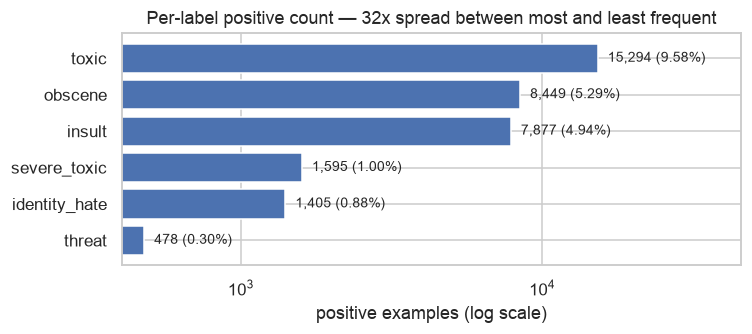

In [2]:
pos_counts = Y.sum(axis=0)
pos_rates = Y.mean(axis=0)

rate_table = pd.DataFrame(
    {
        "positives": pos_counts,
        "negatives": n - pos_counts,
        "positive_rate_%": (100 * pos_rates).round(3),
        "imbalance_ratio": (((n - pos_counts) / pos_counts)).round(1),
    },
    index=LABELS,
).sort_values("positives", ascending=False)
display(rate_table)

fig, ax = plt.subplots(figsize=(7, 3.2))
order = np.argsort(pos_counts)
ax.barh([LABELS[i] for i in order], pos_counts[order], color="#4C72B0")
for i, idx in enumerate(order):
    ax.text(pos_counts[idx] * 1.08, i, f"{pos_counts[idx]:,} ({100*pos_rates[idx]:.2f}%)",
            va="center", fontsize=9)
ax.set_xscale("log")
ax.set_xlim(right=pos_counts.max() * 3)
ax.set_xlabel("positive examples (log scale)")
ax.set_title("Per-label positive count — 32x spread between most and least frequent")
plt.tight_layout()
plt.savefig(RESULTS / "eda_label_rates.png", bbox_inches="tight")
plt.show()

## 2. The all-zeros trap (previewing Phase 2)

Before any modeling, here is why accuracy cannot be the headline metric: a model that
predicts *nothing* — never fires a single label — already scores extremely well on it.

In [3]:
all_zeros_per_label_acc = 1 - pos_rates
all_zeros_subset_acc = float((Y.sum(axis=1) == 0).mean())

preview = pd.DataFrame(
    {"accuracy_of_predicting_always_0": (100 * all_zeros_per_label_acc).round(2)},
    index=LABELS,
).sort_values("accuracy_of_predicting_always_0")
display(preview)

print(f"Exact-match (subset) accuracy of an all-zeros model: {100*all_zeros_subset_acc:.2f}%")
print(f"Mean per-label accuracy of an all-zeros model:       {100*all_zeros_per_label_acc.mean():.2f}%")
print()
print("A model with zero utility scores ~99.7% on `threat`. Every one of those numbers")
print("is worthless: F1 on each label would be exactly 0.0. This is the project's premise.")

,accuracy_of_predicting_always_0
toxic,90.42
obscene,94.71
insult,95.06
severe_toxic,99.00
identity_hate,99.12
threat,99.70


Exact-match (subset) accuracy of an all-zeros model: 89.83%
Mean per-label accuracy of an all-zeros model:       96.33%

A model with zero utility scores ~99.7% on `threat`. Every one of those numbers
is worthless: F1 on each label would be exactly 0.0. This is the project's premise.


## 3. Label co-occurrence

Raw co-occurrence counts, then the conditional probability P(row | column) — the asymmetric
view, which is what actually matters. `identity_hate` almost always implies `toxic`, but
`toxic` rarely implies `identity_hate`.

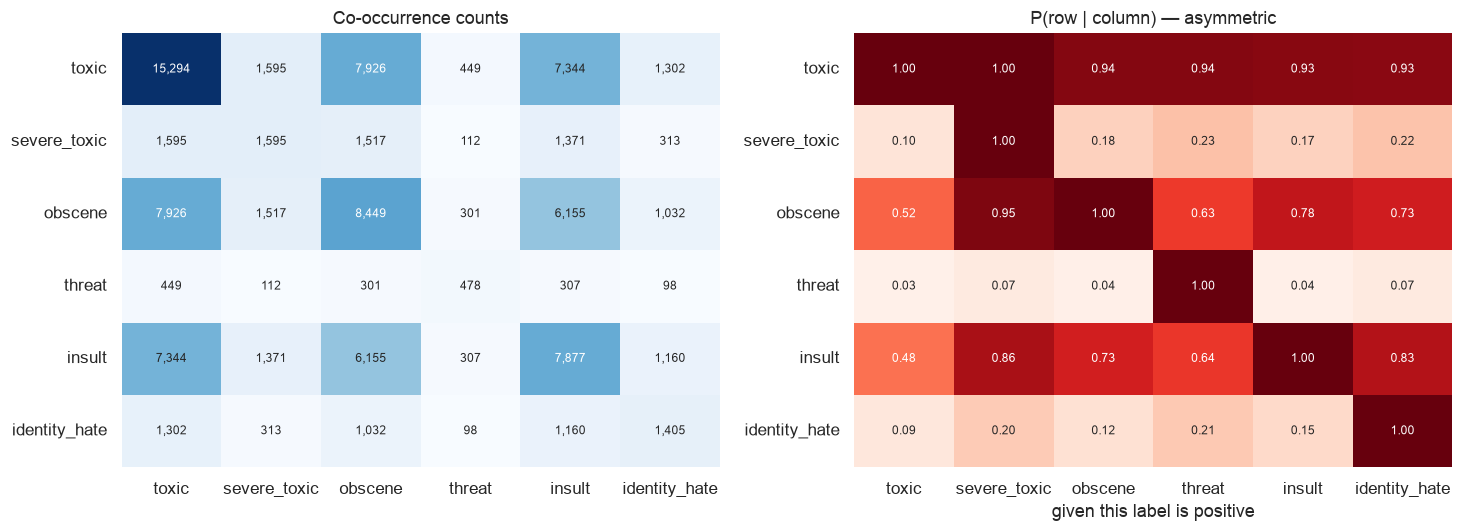

Strongest dependencies P(row | column):
  P(toxic          | severe_toxic  ) = 1.000
  P(obscene        | severe_toxic  ) = 0.951
  P(toxic          | threat        ) = 0.939
  P(toxic          | obscene       ) = 0.938
  P(toxic          | insult        ) = 0.932
  P(toxic          | identity_hate ) = 0.927
  P(insult         | severe_toxic  ) = 0.860
  P(insult         | identity_hate ) = 0.826


In [4]:
# Cast to int64 BEFORE the matmul. Y is int8 to keep 160k x 6 cheap, but int8 @ int8
# stays int8 in numpy and silently wraps around (counts here reach 15,294), producing
# nonsense — including negative "probabilities". np.sum promotes automatically; matmul does not.
Y64 = Y.astype(np.int64)
cooc = Y64.T @ Y64  # (n_labels, n_labels) co-occurrence counts, diagonal = positives
cond = cooc / pos_counts[None, :]  # P(row_label = 1 | column_label = 1)
assert (cond >= 0).all() and (cond <= 1).all(), "conditional probabilities out of range"

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
sns.heatmap(pd.DataFrame(cooc, index=LABELS, columns=LABELS), annot=True, fmt=",d",
            cmap="Blues", ax=axes[0], cbar=False, annot_kws={"size": 8})
axes[0].set_title("Co-occurrence counts")

sns.heatmap(pd.DataFrame(cond, index=LABELS, columns=LABELS), annot=True, fmt=".2f",
            cmap="Reds", ax=axes[1], cbar=False, vmin=0, vmax=1, annot_kws={"size": 8})
axes[1].set_title("P(row | column) — asymmetric")
axes[1].set_xlabel("given this label is positive")
plt.tight_layout()
plt.savefig(RESULTS / "eda_cooccurrence.png", bbox_inches="tight")
plt.show()

print("Strongest dependencies P(row | column):")
pairs = [
    (LABELS[r], LABELS[c], cond[r, c])
    for r in range(len(LABELS)) for c in range(len(LABELS)) if r != c
]
for row, col, p in sorted(pairs, key=lambda t: -t[2])[:8]:
    print(f"  P({row:14s} | {col:14s}) = {p:.3f}")

These dependencies are the motivation for Phase 5/6: One-vs-Rest trains each label with a
*separate* independent classifier, so it has no mechanism to represent
"`identity_hate` implies `toxic`". Classifier chains (Phase 6) do.

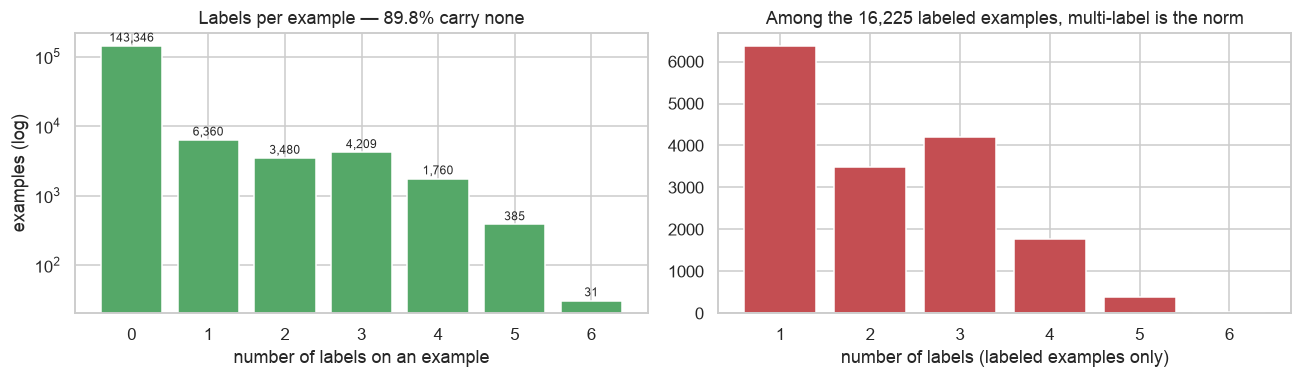

unlabeled:                     143,346 (89.8%)
labeled with exactly 1 label:  6,360
labeled with 2+ labels:        9,865 (60.8% of labeled examples)


In [5]:
n_labels_per_example = Y.sum(axis=1)
dist = pd.Series(n_labels_per_example).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].bar(dist.index, dist.values, color="#55A868")
axes[0].set_yscale("log")
axes[0].set_xlabel("number of labels on an example")
axes[0].set_ylabel("examples (log)")
axes[0].set_title("Labels per example — 89.8% carry none")
for x, v in dist.items():
    axes[0].text(x, v * 1.15, f"{v:,}", ha="center", fontsize=8)

labeled = n_labels_per_example[n_labels_per_example > 0]
axes[1].bar(*np.unique(labeled, return_counts=True), color="#C44E52")
axes[1].set_xlabel("number of labels (labeled examples only)")
axes[1].set_title(f"Among the {len(labeled):,} labeled examples, multi-label is the norm")
plt.tight_layout()
plt.savefig(RESULTS / "eda_labels_per_example.png", bbox_inches="tight")
plt.show()

print(f"unlabeled:                     {(n_labels_per_example == 0).sum():,} ({100*(n_labels_per_example == 0).mean():.1f}%)")
print(f"labeled with exactly 1 label:  {(n_labels_per_example == 1).sum():,}")
print(f"labeled with 2+ labels:        {(n_labels_per_example >= 2).sum():,} "
      f"({100*(n_labels_per_example >= 2).sum()/len(labeled):.1f}% of labeled examples)")

## 4. Text length

Relevant to Phase 3: DistilBERT must truncate somewhere, and we want to know what that costs.

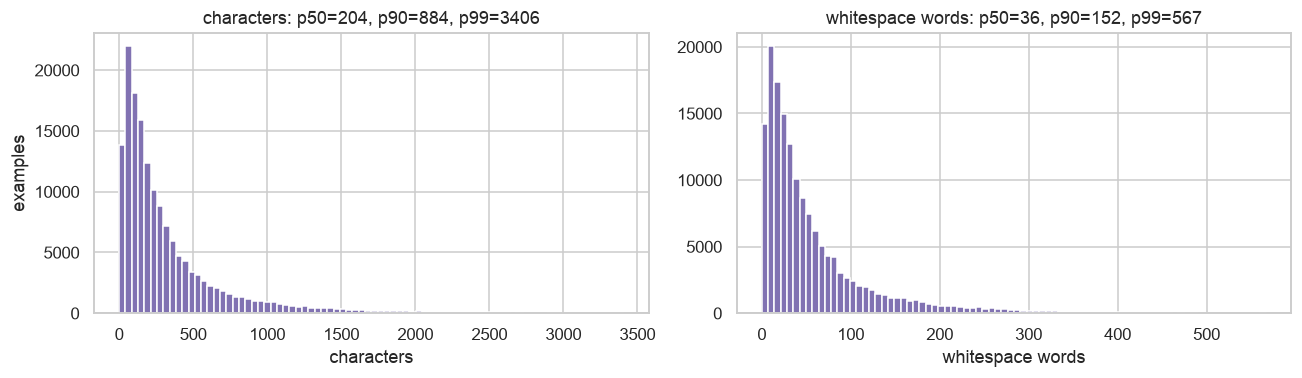

{
  "chars": {
    "p50": 204.0,
    "p75": 432.0,
    "p90": 884.0,
    "p95": 1346.0,
    "p99": 3406.2999999999884,
    "max": 5000,
    "mean": 390.916701656316
  },
  "words": {
    "p50": 36.0,
    "p75": 75.0,
    "p90": 152.0,
    "p95": 230.0,
    "p99": 567.0,
    "max": 1411,
    "mean": 67.27352714465661
  }
}

mean word count by label:
  toxic          positive=   51.3  negative=   69.0
  severe_toxic   positive=   75.6  negative=   67.2
  obscene        positive=   49.6  negative=   68.3
  threat         positive=   55.2  negative=   67.3
  insult         positive=   48.3  negative=   68.3
  identity_hate  positive=   52.0  negative=   67.4


In [6]:
char_len = df["comment_text"].str.len().to_numpy()
word_len = df["comment_text"].str.split().str.len().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, vals, name in [(axes[0], char_len, "characters"), (axes[1], word_len, "whitespace words")]:
    ax.hist(vals, bins=80, range=(0, np.percentile(vals, 99)), color="#8172B2")
    ax.set_xlabel(name)
    ax.set_title(f"{name}: p50={int(np.percentile(vals,50))}, "
                 f"p90={int(np.percentile(vals,90))}, p99={int(np.percentile(vals,99))}")
axes[0].set_ylabel("examples")
plt.tight_layout()
plt.savefig(RESULTS / "eda_text_length.png", bbox_inches="tight")
plt.show()

length_stats = {
    name: {f"p{p}": float(np.percentile(vals, p)) for p in (50, 75, 90, 95, 99)} | {"max": int(vals.max()), "mean": float(vals.mean())}
    for name, vals in [("chars", char_len), ("words", word_len)]
}
print(json.dumps(length_stats, indent=2))

# Does length differ by toxicity? (a cheap check for a confound)
print("\nmean word count by label:")
for i, lab in enumerate(LABELS):
    print(f"  {lab:14s} positive={word_len[Y[:, i] == 1].mean():7.1f}  negative={word_len[Y[:, i] == 0].mean():7.1f}")

## 5. Persist the EDA summary

Written to `results/eda.json` so later phases and the README can reference these numbers
without recomputing them.

In [7]:
splits = load_splits()

eda = {
    "n_examples": int(n),
    "n_labels": len(LABELS),
    "labels": LABELS,
    "seed": SEED,
    "per_label": {
        lab: {
            "positives": int(pos_counts[i]),
            "positive_rate": float(pos_rates[i]),
            "imbalance_ratio_neg_per_pos": float((n - pos_counts[i]) / pos_counts[i]),
        }
        for i, lab in enumerate(LABELS)
    },
    "rare_labels": [LABELS[i] for i in np.argsort(pos_counts)[:2]],
    "all_zeros_baseline": {
        "subset_accuracy": all_zeros_subset_acc,
        "mean_per_label_accuracy": float(all_zeros_per_label_acc.mean()),
        "per_label_accuracy": {lab: float(all_zeros_per_label_acc[i]) for i, lab in enumerate(LABELS)},
        "macro_f1": 0.0,
        "_caveat": "A model predicting no labels at all achieves these accuracies with macro-F1 = 0.0. This is why accuracy is not the headline metric.",
    },
    "cooccurrence_counts": {LABELS[r]: {LABELS[c]: int(cooc[r, c]) for c in range(len(LABELS))} for r in range(len(LABELS))},
    "conditional_probability_row_given_col": {LABELS[r]: {LABELS[c]: float(cond[r, c]) for c in range(len(LABELS))} for r in range(len(LABELS))},
    "labels_per_example": {str(k): int(v) for k, v in dist.items()},
    "text_length": length_stats,
    "split_sizes": {k: int(len(v)) for k, v in splits.items()},
}

(RESULTS / "eda.json").write_text(json.dumps(eda, indent=2))
print(f"wrote {RESULTS / 'eda.json'}")
print("rare labels:", eda["rare_labels"])

wrote /Users/kavana/Documents/text-classifier/results/eda.json
rare labels: ['threat', 'identity_hate']


## Phase 0 findings

**Rare labels.** `threat` (478 positives, **0.30%**) and `identity_hate` (1,405, **0.88%**)
are the rare labels; `severe_toxic` (1,595, 1.00%) is borderline. `threat` carries **333
negatives for every positive**. After the 70/15/15 split it has only **71 positives in
validation and 72 in test** — a caveat Phase 4 has to take seriously, because tuning a
threshold against 71 positives is a genuinely noisy estimate.

**Accuracy is already dead.** An all-zeros model — one that never predicts anything — scores
**89.8% exact-match accuracy**, **96.3% mean per-label accuracy**, and **99.70% on `threat`**,
while achieving macro-F1 of exactly **0.0**. Every later phase reports macro-F1 as the
headline for this reason.

**Co-occurrence is strong and asymmetric.** Every other label is close to a subset of `toxic`:
P(toxic | severe_toxic) = **1.000** exactly (not one severe_toxic comment is un-toxic), and
P(toxic | ·) ≥ **0.927** for all five others. The reverse is weak — P(severe_toxic | toxic) =
0.104. The tightest symmetric pair is `obscene`↔`insult` (**0.781** / **0.728**), which is the
conflation we expect to see in Phase 5's error analysis. One-vs-Rest trains six independent
classifiers and so cannot represent any of this structure — the motivation for Phase 6's
classifier chains.

**Multi-label is the norm where it counts.** 89.8% of comments carry no label, but among the
16,225 that do, **60.8%** carry two or more (and 31 carry all six). Single-label modeling
would be the wrong tool.

**Length.** Median comment is 204 characters / 36 words, but p99 reaches 3,406 characters.
Phase 3 measures the actual token-truncation cost rather than guessing at it.